## 1. Carregamento e Inspeção Inicial

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais para um estilo mais profissional e acadêmico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carregar a base de modelagem
df = pd.read_csv('../data/processed/base_modelagem_brasil.csv', sep=';')


# Visualizando as primeiras linhas e as informações estruturais
display(df.head())
print(df.info())

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,...,feridos_graves,mortos,ano,km_join,icc,icp,icm,cond_pavimento,cond_conservacao,cond_pista
0,571789.0,1269011,2024-01-01,segunda-feira,03:56:00,ES,101,38.0,CONCEICAO DA BARRA,Ultrapassagem Indevida,...,0,0,2024,38,NaN,NaN,NaN,NaN,NaN,NaN
1,571806.0,1269735,2024-01-01,segunda-feira,04:30:00,BA,116,578.0,BREJOES,Ingestão de álcool pelo condutor,...,0,0,2024,578,18.75,20.0,19.625,NaN,NaN,NaN
2,571818.0,1269075,2024-01-01,segunda-feira,06:30:00,SE,101,18.0,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,...,1,0,2024,18,0.00,0.0,0.000,NaN,NaN,NaN
3,571838.0,1269159,2024-01-01,segunda-feira,05:00:00,MT,364,240.0,RONDONOPOLIS,Condutor deixou de manter distância do veículo...,...,0,0,2024,240,30.00,35.0,33.500,NaN,X,NaN
4,571910.0,1269450,2024-01-01,segunda-feira,15:45:00,BA,116,852.9,VITORIA DA CONQUISTA,Chuva,...,0,0,2024,853,30.00,42.5,38.750,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 208919 entries, 0 to 208918
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      208919 non-null  float64
 1   pesid                   208919 non-null  int64  
 2   data_inversa            208919 non-null  str    
 3   dia_semana              208919 non-null  str    
 4   horario                 208919 non-null  str    
 5   uf                      208919 non-null  str    
 6   br                      208919 non-null  int64  
 7   km                      208919 non-null  float64
 8   municipio               208919 non-null  str    
 9   causa_acidente          208919 non-null  str    
 10  tipo_acidente           208919 non-null  str    
 11  classificacao_acidente  208904 non-null  str    
 12  fase_dia                208919 non-null  str    
 13  sentido_via             208919 non-null  str    
 14  condicao_metereologica  208919 

## 2. Tratamento de Valores Nulos
Para variáveis numéricas, podemos preencher dados ausentes com a mediana (que é menos sensível a outliers do que a média). Para variáveis categóricas, podemos preencher com "Não Informado" ou a moda, dependendo da criticidade.

In [36]:
# 1. Identificando as 10 BRs com maior volume de registros
top_10_brs = df['br'].value_counts().nlargest(10).index
print(f"As 10 BRs com mais registros são: {list(top_10_brs)}\n")

# 2. Filtrando o dataset para conter apenas essas 10 BRs
df_top10_brs = df[df['br'].isin(top_10_brs)]

print(f"Quantidade total de registros nas Top 10 BRs: {len(df_top10_brs)}")

# 3. Calculando a quantidade e o percentual de valores nulos nesse subconjunto
nulos_qtd = df_top10_brs.isnull().sum()
nulos_pct = (nulos_qtd / len(df_top10_brs)) * 100

# 4. Criando um DataFrame consolidado para facilitar a visualização
df_nulos_top10 = pd.DataFrame({
    'Quantidade_Nulos': nulos_qtd,
    'Percentual_Nulos(%)': nulos_pct
}).sort_values(by='Quantidade_Nulos', ascending=False)

# 5. Exibindo apenas as colunas que apresentam valores nulos nas Top 10 BRs
colunas_com_nulos = df_nulos_top10[df_nulos_top10['Quantidade_Nulos'] > 0]

print("\nResumo de valores nulos nas Top 10 BRs:")
display(colunas_com_nulos)


As 10 BRs com mais registros são: [101, 116, 153, 364, 230, 316, 158, 10, 174, 242]

Quantidade total de registros nas Top 10 BRs: 208919

Resumo de valores nulos nas Top 10 BRs:


,Quantidade_Nulos,Percentual_Nulos(%)
cond_pavimento,208919,100.000000
cond_pista,208919,100.000000
cond_conservacao,208459,99.779819
icp,114624,54.865283
icc,114624,54.865283
icm,114245,54.683873
sexo,17805,8.522442
tipo_envolvido,17805,8.522442
estado_fisico,17805,8.522442
tipo_veiculo,6901,3.303194


### 2.1. Remoção de colunas

In [37]:
# Retirando as colunas especificadas do dataset das Top 10 BRs
colunas_para_remover = ['cond_pavimento', 'cond_pista', 'cond_conservacao']

# O parâmetro axis=1 indica que estamos removendo colunas (não linhas)
# O uso do 'errors="ignore"' evita que o código quebre caso as colunas já tenham sido removidas rodando a célula duas vezes
df_top10_brs = df_top10_brs.drop(columns=colunas_para_remover, errors='ignore')

print("Colunas removidas com sucesso.")

Colunas removidas com sucesso.


### 2.2. Preenchimento de dados categóricos

In [38]:
# Identificando automaticamente todas as colunas que são de texto (object)
colunas_categoricas = df_top10_brs.select_dtypes(include=['object']).columns

# Preenchendo os valores nulos (NaN) dessas colunas com a string "Não Informado"
df_top10_brs[colunas_categoricas] = df_top10_brs[colunas_categoricas].fillna('Não Informado')

print(f"Valores nulos preenchidos nas colunas categóricas: {list(colunas_categoricas)}")

Valores nulos preenchidos nas colunas categóricas: ['data_inversa', 'dia_semana', 'horario', 'uf', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'tipo_veiculo', 'marca', 'tipo_envolvido', 'estado_fisico', 'sexo']


C:\Users\Computador\AppData\Local\Temp\ipykernel_12968\2459073775.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_top10_brs.select_dtypes(include=['object']).columns


### 2.3. Preenchimento de icp, icc e icm (Interpolação)

In [39]:
colunas_indices = ['icc', 'icp', 'icm']

# Aplicando a interpolação linear (média entre o valor anterior válido e o próximo válido)
df_top10_brs[colunas_indices] = df_top10_brs[colunas_indices].interpolate(method='linear')

# Preenchendo as pontas: se a primeira ou a última linha do arquivo eram nulas, a interpolação não consegue calcular a média.
# O bfill() copia o dado de baixo para cima, e o ffill() copia de cima para baixo nas pontas soltas.
df_top10_brs[colunas_indices] = df_top10_brs[colunas_indices].bfill().ffill()

print("Interpolação das variáveis icc, icp e icm concluída com sucesso.")

# Validação final para garantir que não há mais nenhum nulo no dataset inteiro
print(f"\nQuantidade total de valores nulos no dataset agora: {df_top10_brs.isnull().sum().sum()}")

colunas_indices = ['icc', 'icp', 'icm']

# Aplicando a interpolação linear (média entre o valor anterior válido e o próximo válido)
df_top10_brs[colunas_indices] = df_top10_brs[colunas_indices].interpolate(method='linear')

# Preenchendo as pontas: se a primeira ou a última linha do arquivo eram nulas, a interpolação não consegue calcular a média.
# O bfill() copia o dado de baixo para cima, e o ffill() copia de cima para baixo nas pontas soltas.
df_top10_brs[colunas_indices] = df_top10_brs[colunas_indices].bfill().ffill()

print("Interpolação das variáveis icc, icp e icm concluída com sucesso.")

# Validação final para garantir que não há mais nenhum nulo no dataset inteiro
print(f"\nQuantidade total de valores nulos no dataset agora: {df_top10_brs.isnull().sum().sum()}")


Interpolação das variáveis icc, icp e icm concluída com sucesso.

Quantidade total de valores nulos no dataset agora: 0
Interpolação das variáveis icc, icp e icm concluída com sucesso.

Quantidade total de valores nulos no dataset agora: 0


### 3. Tratamento valores duplicados 

In [40]:
duplicados_antes = df_top10_brs.duplicated().sum()
df_top10_brs = df_top10_brs.drop_duplicates()
print(f"Foram encontrados e removidos {duplicados_antes} registos duplicados.")

# 2. Criando a Variável Alvo (Target)
# Vamos criar uma coluna binária (0 ou 1) chamada 'houve_obito'
# Se a coluna 'mortos' for maior que 0, recebe 1 (Sim). Caso contrário, 0 (Não).
df_top10_brs['houve_obito'] = np.where(df_top10_brs['mortos'] > 0, 1, 0)

# Verificando o balanceamento do nosso alvo
print("\nDistribuição da Variável Alvo (Houve Óbito?):")
print(df_top10_brs['houve_obito'].value_counts(normalize=True) * 100)

# Como já extraímos a informação de óbito, podemos remover as colunas de contagem de vítimas 
# para que o modelo não "faça batota" (não podemos prever se houve óbito usando a coluna 'mortos')
colunas_vazamento = ['mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'estado_fisico']
df_top10_brs = df_top10_brs.drop(columns=colunas_vazamento, errors='ignore')

Foram encontrados e removidos 0 registos duplicados.

Distribuição da Variável Alvo (Houve Óbito?):
houve_obito
0    97.059626
1     2.940374
Name: proportion, dtype: float64


## 4. Análise de Outliers

Neste bloco, utilizamos o método estatístico do **Intervalo Interquartil (IQR)** para identificar e tratar valores discrepantes nos índices da via (`icc`, `icp`, `icm`). 

A estratégia adotada foi o **Capping (Limitação)**: em vez de excluir as linhas e perder dados valiosos, os valores extremos foram substituídos (limitados) pelo teto ou piso matemático da distribuição. Ao final, geramos *boxplots* para validar visualmente que os dados foram ajustados e os picos de ruído foram eliminados.

--- ANÁLISE DE OUTLIERS ---
[ICC] Outliers detectados: 3765
[ICP] Outliers detectados: 9580
[ICM] Outliers detectados: 11210

Tratamento concluído! Todos os outliers foram ajustados para os limites matemáticos aceitáveis.


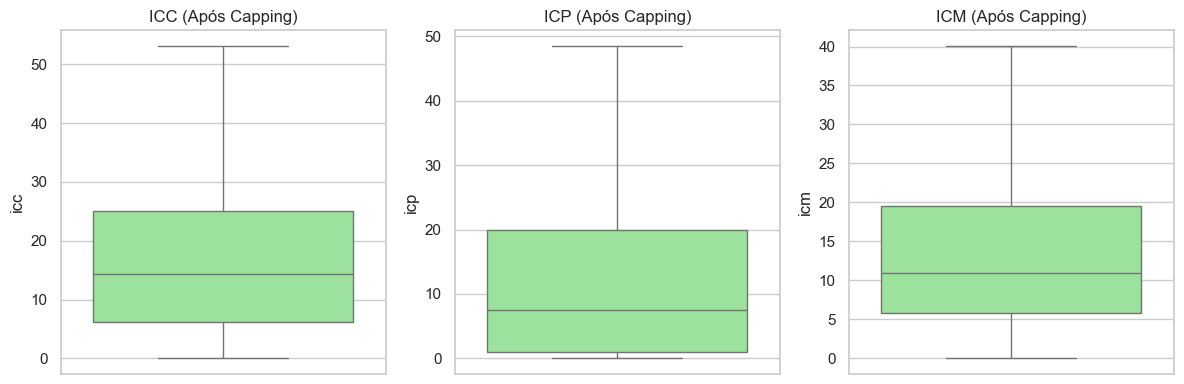

In [41]:
# 1. Definindo as colunas numéricas contínuas para análise
colunas_indices = ['icc', 'icp', 'icm']

# 2. Criando a função que calcula os limites e restringe os valores
def tratar_outliers_iqr(df, coluna):
    # Calculando os quartis
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    
    # Calculando o Interquartil e os limites
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contabilizando quantos outliers existem antes de tratar (apenas para curiosidade)
    qtd_outliers = len(df[(df[coluna] > limite_superior) | (df[coluna] < limite_inferior)])
    print(f"[{coluna.upper()}] Outliers detectados: {qtd_outliers}")
    
    # Aplicando o Capping: Substituindo os extremos pelos limites
    df[coluna] = np.where(df[coluna] > limite_superior, limite_superior, df[coluna])
    df[coluna] = np.where(df[coluna] < limite_inferior, limite_inferior, df[coluna])
    
    return df

# 3. Aplicando a função no nosso dataset
print("--- ANÁLISE DE OUTLIERS ---")
for col in colunas_indices:
    df_top10_brs = tratar_outliers_iqr(df_top10_brs, col)

print("\nTratamento concluído! Todos os outliers foram ajustados para os limites matemáticos aceitáveis.")

# 4. Opcional: Visualizando como ficou a distribuição após o Capping
plt.figure(figsize=(12, 4))
for i, col in enumerate(colunas_indices, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_top10_brs[col], color='lightgreen')
    plt.title(f'{col.upper()} (Após Capping)')

plt.tight_layout()
plt.show()

### 4.1. Encoding

Transformação Texto para Número

In [42]:
# Identificando todas as colunas que ainda são texto (object)
colunas_texto = df_top10_brs.select_dtypes(include=['object']).columns
print(f"Variáveis a serem analisadas para codificação: {list(colunas_texto)}\n")

# Removendo colunas de alta cardinalidade ou identificadores textuais soltos
colunas_ignorar = [
    'data_inversa', 'horario', 'municipio', 'marca', 'causa_acidente', 'uf',
    'tracado_via', 
    'id', 'pesid', 'id_veiculo', 'km_join' 
]
colunas_para_codificar = [col for col in colunas_texto if col not in colunas_ignorar]

# Dropando do dataset as colunas que não vão para o modelo
df_top10_brs = df_top10_brs.drop(columns=colunas_ignorar, errors='ignore')

# Aplicando o One-Hot Encoding (get_dummies)
# drop_first=True evita a armadilha da multicolinearidade
df_final = pd.get_dummies(df_top10_brs, columns=colunas_para_codificar, drop_first=True)

# Convertendo booleanos para inteiros (0 e 1)
for col in df_final.columns:
    if df_final[col].dtype == 'bool':
        df_final[col] = df_final[col].astype(int)

print(f"Formato final (Pronto para Modelagem): {df_final.shape}")

C:\Users\Computador\AppData\Local\Temp\ipykernel_12968\729855273.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df_top10_brs.select_dtypes(include=['object']).columns


Variáveis a serem analisadas para codificação: ['data_inversa', 'dia_semana', 'horario', 'uf', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'tipo_veiculo', 'marca', 'tipo_envolvido', 'sexo']

Formato final (Pronto para Modelagem): (208919, 83)


## 5. Exportação Dados Tratados

In [43]:
import os

# 1. Definindo o caminho da pasta e o nome do arquivo
pasta_destino = '../data/processed/data_model'
nome_arquivo = 'data_model.csv'

# 2. Garantindo que a estrutura de pastas exista (cria as pastas se não existirem)
os.makedirs(pasta_destino, exist_ok=True)

# 3. Juntando a pasta com o nome do arquivo para ter o caminho completo
caminho_completo = os.path.join(pasta_destino, nome_arquivo)

# 4. Exportando o dataset
df_final.to_csv(caminho_completo, index=False, sep=';')

print(f"Sucesso! Dataset final exportado em: '{caminho_completo}'")
print("O Notebook de AED e Preparação pode ser encerrado.")

Sucesso! Dataset final exportado em: '../data/processed/data_model\data_model.csv'
O Notebook de AED e Preparação pode ser encerrado.
